# Write a Python code to interpret a perceptron

In [7]:
import numpy as np
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# Training Data
# [Study, Attendance]
X = np.array([
    [1, 50],
    [2, 55],
    [3, 60],
    [5, 75],
    [6, 80],
    [7, 85]
])

# Target
# 0 = Fail, 1 = Pass
y = np.array([0, 0, 0, 1, 1, 1])

# Create Perceptron Model
model = Perceptron(max_iter=1000, random_state=42)

# Train the Model
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Display Results
print("Actual Values   :", y)
print("Predicted Values:", y_pred)

# Accuracy
accuracy = accuracy_score(y, y_pred)
print("Accuracy :", accuracy * 100, "%")

# Model Parameters
print("\nWeights :", model.coef_)
print("Bias    :", model.intercept_)

# Predict a New Student
new_student = np.array([[4, 70]])

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("\nNew Student Prediction : PASS")
else:
    print("\nNew Student Prediction : FAIL")

Actual Values   : [0 0 0 1 1 1]
Predicted Values: [0 0 0 0 0 0]
Accuracy : 50.0 %

Weights : [[ 38. -15.]]
Bias    : [-6.]

New Student Prediction : FAIL


# Write a Python code to interpret a percepton with decision boundary

Actual Values    : [0 0 0 1 1 1]
Predicted Values : [0 0 0 1 1 1]

New Student Prediction : PASS


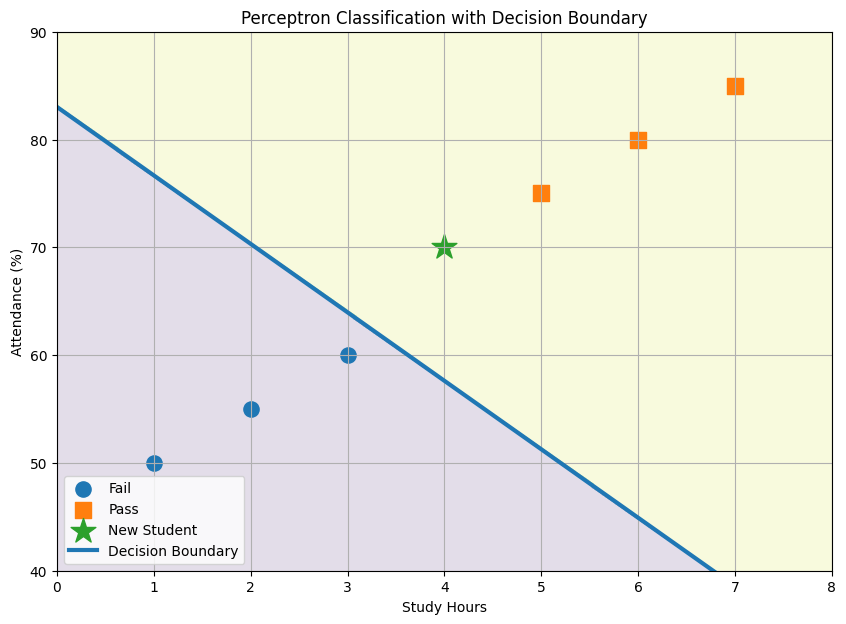

In [8]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# --------------------------------------------------
# Dataset
# --------------------------------------------------
# Features: [Study Hours, Attendance]
X = np.array([
    [1, 50],
    [2, 55],
    [3, 60],
    [5, 75],
    [6, 80],
    [7, 85]
])

# Target
# 0 = Fail, 1 = Pass
y = np.array([0, 0, 0, 1, 1, 1])


# --------------------------------------------------
# Perceptron with Scaling
# --------------------------------------------------
model = make_pipeline(
    StandardScaler(),
    Perceptron(max_iter=1000, random_state=42)
)

# Train the Model
model.fit(X, y)

# Predictions
predictions = model.predict(X)

print("Actual Values    :", y)
print("Predicted Values :", predictions)


# --------------------------------------------------
# Predict a New Student
# --------------------------------------------------
new_student = np.array([[4, 70]])

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("\nNew Student Prediction : PASS")
else:
    print("\nNew Student Prediction : FAIL")


# --------------------------------------------------
# Create Grid for Decision Regions
# --------------------------------------------------
X_min, X_max = 0, 8
y_min, y_max = 40, 90

xx, yy = np.meshgrid(
    np.linspace(X_min, X_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = model.predict(grid)
Z = Z.reshape(xx.shape)


# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(10, 7))

# Decision Regions
plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.15
)

# Fail Points
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    marker='o',
    s=120,
    label='Fail'
)

# Pass Points
plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    marker='s',
    s=120,
    label='Pass'
)

# New Student
plt.scatter(
    new_student[0, 0],
    new_student[0, 1],
    marker='*',
    s=350,
    label='New Student'
)


# --------------------------------------------------
# Get Transformed-Space Coefficients
# --------------------------------------------------
scaler = model.named_steps['standardscaler']
perceptron = model.named_steps['perceptron']

w = perceptron.coef_[0]
b = perceptron.intercept_[0]


# --------------------------------------------------
# Convert Boundary Back to Original Feature Space
# --------------------------------------------------
mean = scaler.mean_
scale = scaler.scale_

w_original = w / scale

b_original = b - np.sum(w * mean / scale)


# --------------------------------------------------
# Calculate Decision Boundary
# --------------------------------------------------
x_values = np.linspace(0, 8, 100)

y_values = -(
    w_original[0] * x_values + b_original
) / w_original[1]


# Plot Decision Boundary
plt.plot(
    x_values,
    y_values,
    linewidth=3,
    label='Decision Boundary'
)


# --------------------------------------------------
# Graph Labels
# --------------------------------------------------
plt.xlabel("Study Hours")
plt.ylabel("Attendance (%)")
plt.title("Perceptron Classification with Decision Boundary")

plt.legend()
plt.grid(True)

plt.xlim(0, 8)
plt.ylim(40, 90)

plt.show()



# KNN Classification with Visualization

Actual Values    : [0 0 0 1 1 1]
Predicted Values : [0 0 0 1 1 1]
Accuracy         : 100.0 %

New Student
Study Hours : 4
Attendance  : 70 %
Prediction  : PASS

3 Nearest Students:
Student 4: Study Hours = 5, Attendance = 75%, Class = PASS, Distance = 0.60
Student 3: Study Hours = 3, Attendance = 60%, Class = FAIL, Distance = 0.89
Student 5: Study Hours = 6, Attendance = 80%, Class = PASS, Distance = 1.20


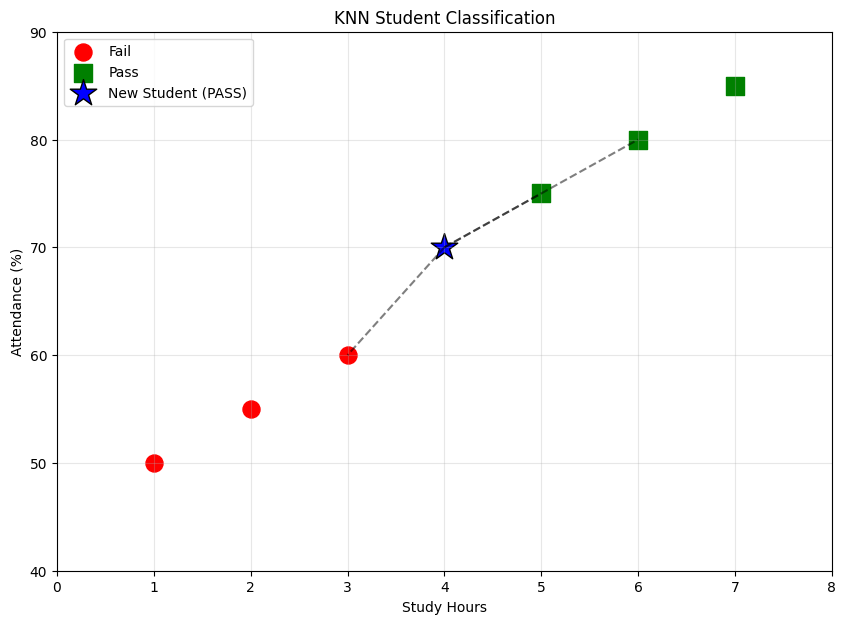

In [9]:

# KNN Classification with Visualization

import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score


# ==========================================================
# Dataset
# ==========================================================
# Features: [Study Hours, Attendance]

X = np.array([
    [1, 50],
    [2, 55],
    [3, 60],
    [5, 75],
    [6, 80],
    [7, 85]
])

# Target
# 0 = Fail, 1 = Pass

y = np.array([0, 0, 0, 1, 1, 1])


# ==========================================================
# KNN Model
# ==========================================================

model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=3)
)

# Train the Model
model.fit(X, y)


# ==========================================================
# Prediction on Training Data
# ==========================================================

y_pred = model.predict(X)

accuracy = accuracy_score(y, y_pred)

print("Actual Values    :", y)
print("Predicted Values :", y_pred)
print("Accuracy         :", accuracy * 100, "%")


# ==========================================================
# Test Student
# ==========================================================

new_student = np.array([[4, 70]])

prediction = model.predict(new_student)[0]

if prediction == 1:
    result = "PASS"
else:
    result = "FAIL"

print("\nNew Student")
print("Study Hours :", new_student[0, 0])
print("Attendance  :", new_student[0, 1], "%")
print("Prediction  :", result)


# ==========================================================
# Find 3 Nearest Neighbors
# ==========================================================

scaler = model.named_steps["standardscaler"]
knn = model.named_steps["kneighborsclassifier"]

# Scale the data
X_scaled = scaler.transform(X)
new_scaled = scaler.transform(new_student)

# Find nearest neighbors
distances, indices = knn.kneighbors(new_scaled)

print("\n3 Nearest Students:")

for i in range(3):

    index = indices[0][i]

    if y[index] == 1:
        student_class = "PASS"
    else:
        student_class = "FAIL"

    print(
        f"Student {index + 1}: "
        f"Study Hours = {X[index, 0]}, "
        f"Attendance = {X[index, 1]}%, "
        f"Class = {student_class}, "
        f"Distance = {distances[0][i]:.2f}"
    )


# ==========================================================
# Visualization
# ==========================================================

plt.figure(figsize=(10, 7))


# Fail Students
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    color="red",
    marker="o",
    s=150,
    label="Fail"
)


# Pass Students
plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    color="green",
    marker="s",
    s=150,
    label="Pass"
)


# New Student
plt.scatter(
    new_student[0, 0],
    new_student[0, 1],
    color="blue",
    marker="*",
    s=400,
    edgecolor="black",
    label=f"New Student ({result})"
)


# ==========================================================
# Draw Lines to 3 Nearest Neighbors
# ==========================================================

for i in range(3):

    index = indices[0][i]

    plt.plot(
        [new_student[0, 0], X[index, 0]],
        [new_student[0, 1], X[index, 1]],
        "k--",
        alpha=0.5
    )


# ==========================================================
# Graph Labels
# ==========================================================

plt.xlabel("Study Hours")
plt.ylabel("Attendance (%)")

plt.title("KNN Student Classification")

plt.xlim(0, 8)
plt.ylim(40, 90)

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

